In [51]:
# Imports neccessary libraries that this project uses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub


In [52]:
path = kagglehub.dataset_download("munumbutt/superconductor-dataset")
for i in os.listdir(path):
    print(i) # Downloads and prints the csv name from kaggle

df = pd.read_csv(os.path.join(path, "train.csv")) # Load the dataset into a DataFrame (df) so we can work with it in pandas.

print(df.shape) # Prints the number of rows and columns in the data
print(df.info()) #Column names, data types and non null counts
print(df.isna().sum()) # Counts how many missing values (we dont have any)
print(df.duplicated().sum()) # counts exact duplicate rows (we have 66)
print(df.describe())  # summary stats (mean, std, min, max, quartiles) per numeric column - used to spot outliers, weird values, or scale differences
df.head() # This prints the first 5 rows of each column


train.csv
(21263, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [53]:
# Were just getting rid of those 66 duplicates now

Before = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {Before - df.shape[0]} duplicates, {df.shape[0]} rows left")

Removed 66 duplicates, 21197 rows left


count    21197.00
mean        34.49
std         34.28
min          0.00
25%          5.38
50%         20.00
75%         63.00
max        185.00
Name: critical_temp, dtype: float64
Skewness:  0.86


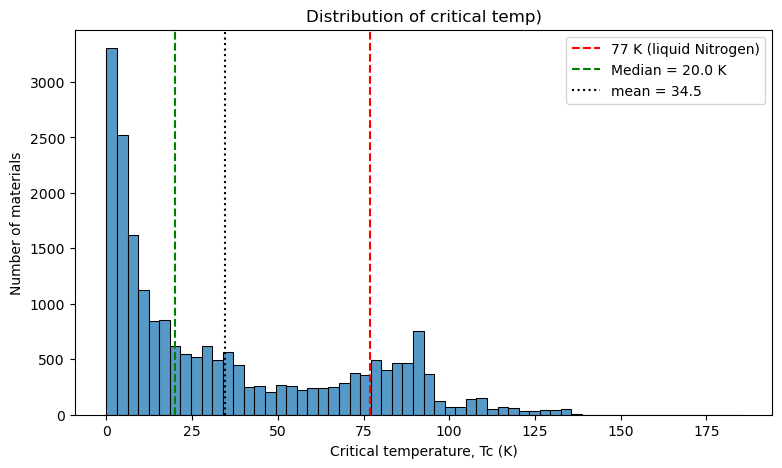

In [ ]:
tc = df["critical_temp"] #tc means "critical temperature" so we dont have to keep typing out df[xx] whenever we want it 

print(tc.describe().round(2))
print(f"Skewness: {tc.skew(): .2f}") #measures how lopsided our distribution is 

fig, ax = plt.subplots(figsize=(9, 5)) # creates the figure and the one are plot
sns.histplot(tc, bins=60, ax=ax)
ax.axvline(77, color="red", linestyle="--", label="77 K (liquid Nitrogen)")  # sets line at 77K
ax.axvline(tc.median(), color="green", linestyle="--", label=f"Median = {tc.median():.1f} K") # Line at 
ax.axvline(tc.mean(), color="black", linestyle="", label=f"mean = {tc.mean():.1f}")

ax.set_xlabel("Critical temperature, Tc (K)") #Labels x axis
ax.set_ylabel("Number of materials") #Y axis
ax.set_title("Distribution of critical temp)") 
ax.legend()
plt.show()



In [55]:
above_77K = (tc > 77).mean() * 100
print(f"{above_77K:.1f}% of materials above 77 Kelvin with {(tc > 77).sum()} materials")

18.4% of materials above 77 Kelvin with 3894 materials



Tc ranges from near 0 K to 185 K, with a median of 20.0 K and a mean of 34.5 K. The distribution is right-skewed (skewness 0.86) and bimodal: most materials sit below 15 K, with a second cluster around 75–95 K, likely the cuprate family. 18.4% of materials (3,894) have Tc above 77 K, the boiling point of liquid nitrogen, so the classification task in section 6 is moderately imbalanced.
